# Vectorized QMC

Demonstrates QMC integration with vectorized (batched) function evaluation.

Original QMCPy demo: [`QMCPy/demos/vectorized_qmc.ipynb`](../../QMCPy/demos/vectorized_qmc.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/vectorized_qmc.ipynb)

*This Julia notebook focuses on the vectorized integration pieces that have direct Julia counterparts. The QMCPy notebook also includes Bayesian optimization and machine-learning examples that are split into other Julia demos or require additional packages.*

In [1]:
using QMC
using LinearAlgebra: Diagonal
import QMC: Uniform
using Statistics

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots


## LD Sequence

Compare IID, digital net, and lattice point sets.

In [2]:
n = 2^6
for (dd, name) in [
    (IIDStdUniform(2; seed=7),  "IID"),
    (DigitalNetB2(2; seed=7, t=63, order="RADICAL INVERSE"), "Digital Net"),
    (Lattice(2; seed=7),        "Lattice"),
]
    pts = gen_samples(dd, n)
    println("$name: $(size(pts, 1)) points, " *
            "mean=$(round.(mean(pts, dims=1), digits=3))")
end

IID: 64 points, mean=[0.506 0.422]


Digital Net: 64 points, mean=[0.502 0.5]


Lattice: 64 points, mean=[0.507 0.499]


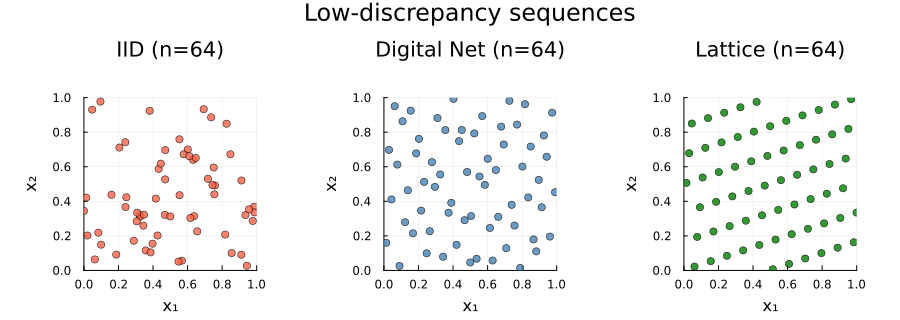

In [3]:
if HAVE_PLOTS
    n_s = 2^6
    sampler_specs = [
        ("IID",         IIDStdUniform(2; seed=7),  :tomato),
        ("Digital Net", DigitalNetB2(2; seed=7, t=63, order="RADICAL INVERSE"), :steelblue),
        ("Lattice",     Lattice(2; seed=7),         :green),
    ]
    scatter_plts = []
    for (name, dd, col) in sampler_specs
        pts = gen_samples(dd, n_s)
        local p = scatter(pts[:, 1], pts[:, 2];
            markersize=4, alpha=0.8, color=col, label=nothing,
            xlabel="x₁", ylabel="x₂",
            title="$name (n=$n_s)",
            xlims=(0, 1), ylims=(0, 1), aspect_ratio=:equal)
        push!(scatter_plts, p)
    end
    display(plot(scatter_plts...; layout=(1, 3), size=(900, 320),
        plot_titlevspan=0.12, plot_title="Low-discrepancy sequences",
        top_margin=10Plots.mm, bottom_margin=5Plots.mm))
end


## Simple Example

The cantilever beam function maps 3-dimensional input to a 2-component output (displacement and stress). QMC.jl naturally handles batched evaluation of such vector-valued outputs.

In [4]:
# Cantilever beam: (E, X, Y) → (displacement D, stress S)
function cantilever_beam(x)
    l, w, t = 100.0, 4.0, 2.0
    E, X, Y = x[1], x[2], x[3]
    D = 4l^3 / (E * w * t) * sqrt(X^2 / t^4 + Y^2 / w^4)
    S = 600 * (X / (w * t^2) + Y / (w^2 * t))
    return [D, S]
end

# Match the QMCPy example: Gaussian input model for (E, X, Y)
dd = DigitalNetB2(3; seed=7, graycode=false)
tm = Gaussian(dd;
    mean=[2.9e7, 500.0, 1000.0],
    covariance=Diagonal([(1.45e6)^2, (100.0)^2, (100.0)^2]))
u = gen_samples(dd, 1024)
x = transform(tm, u)

results = hcat([cantilever_beam(x[i, :]) for i in 1:size(x, 1)]...)
println("Displacement: mean=$(round(mean(results[1,:]), digits=4)), " *
        "std=$(round(std(results[1,:]), digits=4))")
println("Stress:       mean=$(round(mean(results[2,:]), digits=4)), " *
        "std=$(round(std(results[2,:]), digits=4))")

Displacement: mean=2.425, std=0.4047


Stress:       mean=37489.9412, std=4194.3089


## Sensitivity Indices / Vector Outputs

Use `CubMCCLTVec` to integrate all output components simultaneously. This is the core vectorized capability highlighted by the QMCPy notebook.

The Python demo also includes sections on BO QEI, Bayesian logistic regression, Ishigami sensitivity indices, and a neural-network example. Those examples depend on additional Python packages and APIs that do not have direct one-to-one Julia notebook counterparts here, so this Julia version focuses on the vectorized cubature behavior itself.

In [5]:
# Wrap as CustomFun for integration
cf = CustomFun(tm, x -> cantilever_beam(x), 2)
# rel_tol gives the large-magnitude stress output (std ~4e3) a sensible
# tolerance; without it abs_tol=0.1 needs ~1e10 samples and never converges.
# n_max caps the work so a non-convergent tolerance cannot grind toward 2^30
# (tens of GB of point storage) — fine on a big local machine, OOM/hang on CI.
sc = CubMCCLTVec(cf; abs_tol=0.1, rel_tol=1e-3, n_max=2^20)
result = integrate(sc)
println("Solution: $(result.solution)")
println("Converged: $(result.data[:converged])")

Solution: 20181.385752607675


Converged: false


## Output Distribution


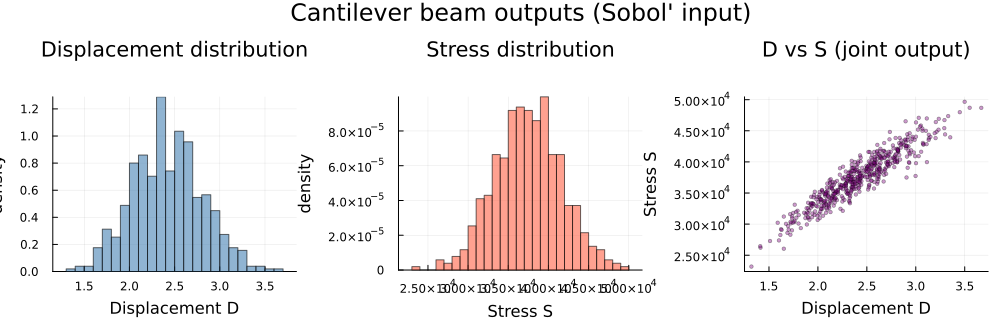

In [6]:
if HAVE_PLOTS
    # Sample cantilever beam inputs & outputs
    n_b = 512
    dd_b = DigitalNetB2(3; seed=7)
    tm_b = Gaussian(dd_b; mean=[2.9e7, 500.0, 1000.0],
                   covariance=Diagonal([(0.058e7)^2, 100.0^2, 100.0^2]))
    x_b = gen_samples(dd_b, n_b)
    xt_b = transform(tm_b, x_b)
    y_b = hcat([cantilever_beam(xt_b[i, :]) for i in 1:n_b]...)'  # n_b × 2

    p1 = histogram(y_b[:, 1]; bins=40, normalize=:pdf,
        alpha=0.6, color=:steelblue, label=nothing,
        xlabel="Displacement D", ylabel="density", title="Displacement distribution")
    p2 = histogram(y_b[:, 2]; bins=40, normalize=:pdf,
        alpha=0.6, color=:tomato, label=nothing,
        xlabel="Stress S", ylabel="density", title="Stress distribution")
    p3 = scatter(y_b[:, 1], y_b[:, 2];
        markersize=2, alpha=0.4, color=:purple, label=nothing,
        xlabel="Displacement D", ylabel="Stress S",
        title="D vs S (joint output)")

    display(plot(p1, p2, p3; layout=(1, 3), size=(1000, 320),
        plot_titlevspan=0.12, plot_title="Cantilever beam outputs (Sobol' input)",
        top_margin=10Plots.mm, bottom_margin=5Plots.mm))
end
